In [23]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [24]:
subgraphllm = ChatGroq(
    model="openai/gpt-oss-120b"
)
parentllm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [25]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [26]:
def translate_text(state: SubState):

    prompt = f"""
                Translate the following text to German.
                Keep it natural and clear. Do not add extra content.
                Text:
                {state["input_text"]}
                """.strip()
    
    translated_text = subgraphllm.invoke(prompt).content

    return {'translated_text': translated_text}

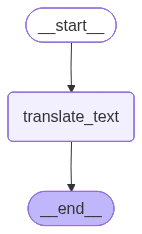

In [28]:
subgraph = StateGraph(SubState)
subgraph.add_node('translate_text', translate_text)
subgraph.add_edge(START, 'translate_text')
subgraph.add_edge('translate_text', END)

subflow = subgraph.compile()
subflow


In [29]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_germ: str

In [30]:
def generate_answer(state: ParentState):
    answer = parentllm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [31]:
def translate_answer(state: ParentState):
    result = subflow.invoke({'input_text': state['answer_eng']})
    return {'answer_germ': result['translated_text']}


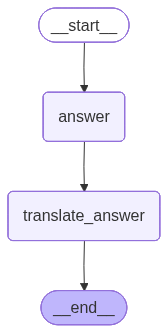

In [32]:
graph = StateGraph(ParentState)
graph.add_node('answer', generate_answer)
graph.add_node('translate_answer', translate_answer)
graph.add_edge(START, 'answer')
graph.add_edge('answer', 'translate_answer')
graph.add_edge('translate_answer', END)

workflow = graph.compile()
workflow

In [56]:
answer = workflow.invoke({'question': 'What is the capital of Germany?'})

In [57]:
answer['answer_eng'], answer['answer_germ']

('The capital of Germany is **Berlin**.',
 'Die Hauptstadt von Deutschland ist **Berlin**.')